Operación exitosa: 0 filas afectadas.
0 ('Americas', 32)
1 ('Europe', 8)
Error: 'value' must be an instance of str or bytes, not a int


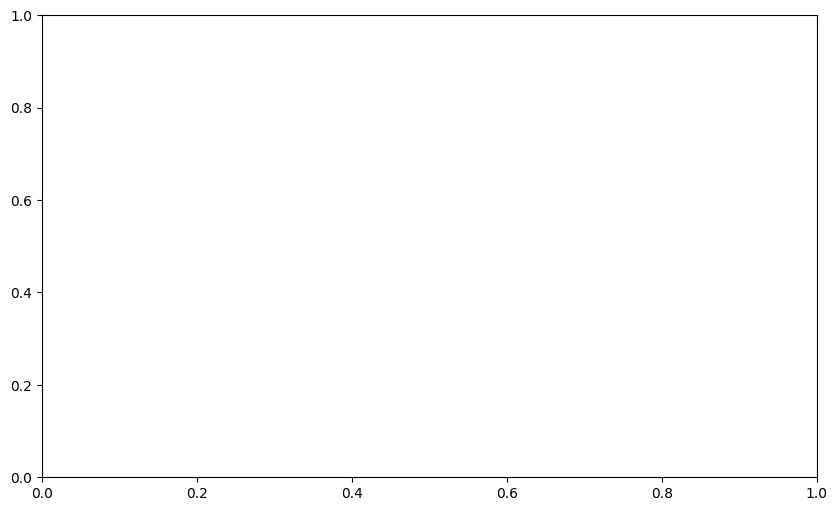

In [2]:
import oracledb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = oracledb.connect(
    user="hr",
    password="basededatos",
    dsn="localhost:1521/XE"
)

#FUNCIÓN PARA EJECUTAR DML (Insert/Update/Delete)
def ejecutar_dml(sql):
    cursor = conn.cursor()
    try:
        cursor.execute(sql)
        #conn.commit()
        print(f"Operación exitosa: {cursor.rowcount} filas afectadas.")
        resultados = cursor.fetchall()
        i = 0
        for row in resultados:
            print(i, row)
            i = i + 1

        plt.figure(figsize=(10,6))
        plt.bar(resultados[0], resultados[1])
        plt.title('Empleados por region')
        plt.xlabel('Region')
        plt.ylabel('Numero de empleados')
        plt.show()
    except Exception as e:
        print(f"Error: {e}")
        #conn.rollback()
    finally:
        cursor.close()

# BLOQUE 3: FUNCIÓN PARA VER Y GRAFICAR (El truco del Caso de Estudio)
def ver_datos(sql_consulta):
    # Pandas lee SQL directo y te devuelve una tabla bonita
    df = pd.read_sql(sql_consulta, conn)
    display(df.head()) # Muestra las primeras filas
    return df

ejecutar_dml(
"""
SELECT r.region_name, COUNT(e.employee_id) AS "Numero de Empleados" FROM employees e
JOIN departments d ON e.department_id = d.department_id
JOIN locations l ON d.location_id = l.location_id
JOIN countries c ON l.country_id = c.country_id
JOIN regions r ON c.region_id = r.region_id
GROUP BY (r.region_name)
""")


--- Datos Recuperados ---


C:\Users\HP\AppData\Local\Temp\ipykernel_5812\2994487586.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql_consulta, conn)


,REGION_NAME,Numero de Empleados
0,Americas,32
1,Europe,8


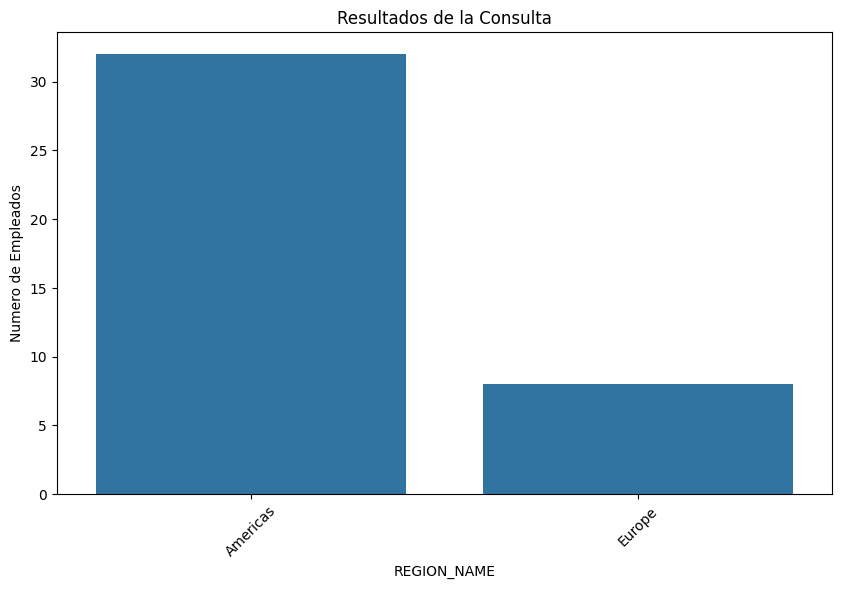

In [4]:
import oracledb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = oracledb.connect(
    user="hr",
    password="basededatos",
    dsn="localhost:1521/XE"
)

# ---------------------------------------------------------
# FUNCIÓN 1: SOLO PARA CAMBIAR DATOS (DML)
# Úsala para INSERT, UPDATE, DELETE. No grafica, solo actúa.
# ---------------------------------------------------------
def ejecutar_dml(sql):
    cursor = conn.cursor()
    try:
        cursor.execute(sql)
        #conn.commit() # ¡Importante guardar cambios!
        print(f"✅ Operación exitosa: {cursor.rowcount} filas afectadas.")
    except Exception as e:
        print(f"❌ Error: {e}")
        #conn.rollback()
    finally:
        cursor.close()

# ---------------------------------------------------------
# FUNCIÓN 2: SOLO PARA VER Y GRAFICAR (SELECT)
# Úsala para verificar los resultados visualmente
# ---------------------------------------------------------
def graficar_resultados(sql_consulta):
    # Pandas hace el trabajo sucio de ordenar los datos
    df = pd.read_sql(sql_consulta, conn)
    
    # Mostramos la tabla primero
    print("--- Datos Recuperados ---")
    display(df) 
    
    # Graficamos usando el DataFrame (mucho más fácil que usar listas)
    if not df.empty:
        plt.figure(figsize=(10,6))
        # OJO: x=Nombre de la columna en BD, y=Nombre de la columna numérica
        sns.barplot(data=df, x=df.columns[0], y=df.columns[1])
        plt.title('Resultados de la Consulta')
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("⚠️ La consulta no devolvió datos para graficar.")

# ==========================================
# PRUEBA EN VIVO
# ==========================================

# 1. Primero defines tu query de visualización
query_region = """
SELECT r.region_name, COUNT(e.employee_id) AS "Numero de Empleados" 
FROM employees e
JOIN departments d ON e.department_id = d.department_id
JOIN locations l ON d.location_id = l.location_id
JOIN countries c ON l.country_id = c.country_id
JOIN regions r ON c.region_id = r.region_id
GROUP BY (r.region_name)
"""

# 2. Llamas a la función de graficar
graficar_resultados(query_region)

In [ ]:
query = """
SELECT first_name, employee_id, salary FROM employees
ORDER BY salary
"""
cursor = conn.cursor()
cursor.execute(query)
resultado = cursor.fetchall()
columnas = ['Nombre', 'ID', 'Salario']
df = pd.DataFrame(resultado, columns=columnas).head(5)
print(df)


   Nombre   ID  Salario
0   Karen  119   2500.0
1     Guy  118   2600.0
2   Irene  126   2700.0
3   Sigal  117   2800.0
4  Shelli  116   2900.0
QUE GAY DEIVIS
